# Eigenfaces Olivetti

## Εγκατάσταση των Απαραίτητων Βιβλιοθηκών

In [ ]:
%pip install --upgrade pip
%pip install --upgrade scipy
%pip install --upgrade numpy
%pip install --upgrade scikit-learn
%pip install --upgrade pandas

## Φόρτωση Βιβλιοθηκών

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


/var/folders/dn/70lvzndj20ndh0_4xhf63ff80000gn/T/ipykernel_14492/3624083923.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Φόρτωση των Δεδομένων και Εμφάνιση των Μεταβλητών

In [3]:
mat_data = scipy.io.loadmat('/Users/marina/Python/Olivetti/olivetti.mat')
mat_contents = scipy.io.whosmat('/Users/marina/Python/Olivetti/olivetti.mat')
print(mat_contents)

X = mat_data['X']
y = mat_data['label'].reshape(-1)


[('X', (400, 4096), 'double'), ('label', (400, 1), 'double')]


## Reshape and Convert Into Dataframe

In [4]:
image_vector = [list(X) for X in zip(*X)]
image_number = [str(i+1) for i in range(400)]
df = pd.DataFrame(image_vector, columns=image_number)
print('\n', df)


        1    2   3    4    5    6   7   8   9   10  ...  391  392  393  394  \
0     75  110  77   48  121  133  80  31  59   92  ...  132   81  110  125   
1     83  108  75   53  116  133  78  32  53   94  ...  132   81  109  124   
2     83  120  65   58  119  138  79  32  60   89  ...  132   80  109  114   
3     74  127  53   55  119  141  84  31  59   93  ...  134   75  107  112   
4     81  130  49   57  120  138  86  33  55  108  ...  134   71  109  115   
...   ..  ...  ..  ...  ...  ...  ..  ..  ..  ...  ...  ...  ...  ...  ...   
4091  39   37  37  177   48  166  40  48  44   44  ...   40   93   94   84   
4092  41   39  37  177   44  170  38  44  47   46  ...   38   94   95   83   
4093  42   35  37  178   47  171  39  43  47   43  ...   44   93   93   76   
4094  40   33  38  180   40  171  38  45  47   39  ...   46   93   96   86   
4095  38   37  37  179   42  170  37  42  46   42  ...   44   93   93   88   

      395  396  397  398  399  400  
0      70   97   89  121

## Convert the Dataframe Into Numpy Array & Reshape Data Into Images

In [5]:
data = df.to_numpy()
print('\n', data)

images = data.reshape(64,64, 400)
images = np.rot90(images, 3)

fig, axs = plt.subplots(40, 10, figsize=(100, 300))
fig.tight_layout()

for i, ax in enumerate(axs.flat):
    ax.imshow(images[:, :, i], cmap='bone')
    ax.axis('off')
plt.show()


 [[ 75 110  77 ... 121  52 125]
 [ 83 108  75 ... 119  49 125]
 [ 83 120  65 ... 113  51 125]
 ...
 [ 42  35  37 ...  41 143  96]
 [ 40  33  38 ...  45 144  91]
 [ 38  37  37 ...  46 146  93]]


## Transpose the Dataframe

In [6]:
df_transposed = df.transpose()
print('\n', df_transposed)

labels = np.array(y)
print('\n', labels)


      0     1     2     3     4     5     6     7     8     9     ...  4086  \
1      75    83    83    74    81    76    75    64    60    64  ...    41   
2     110   108   120   127   130   142   162   169   171   166  ...    38   
3      77    75    65    53    49    50    47    43    48    64  ...    38   
4      48    53    58    55    57    52    45    34    20    29  ...   154   
5     121   116   119   119   120   127   141   141   141   140  ...    44   
..    ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   ...   
396    97   102   104    95    93    93    95    99   103   103  ...    41   
397    89    88    88    89    88    87    88    85    81    83  ...   116   
398   121   119   113   114   118   121   125   129   135   140  ...    43   
399    52    49    51    55    61    68    73    73    73    69  ...   128   
400   125   125   125   120   120   117   116   117   116   116  ...    88   

     4087  4088  4089  4090  4091  4092  4093  4094  4095  
1

## Split the Dataset

In [7]:
X_train, X_test, y_train, y_test = train_test_split(df_transposed, labels, test_size=0.2, random_state=42, stratify=y)
print('\n Train-Test Split:')
print('\n Train:', X_train.index, '\n Test:', X_test.index)
print(any(x in X_train.index for x in X_test.index))

print('\n X_train shape is:', X_train.shape)
print('\n X_test shape is:', X_test.shape)


 Train-Test Split:

 Train: Index(['140', '59', '35', '127', '110', '203', '246', '356', '113', '134',
       ...
       '41', '296', '125', '3', '52', '197', '279', '217', '30', '61'],
      dtype='object', length=320) 
 Test: Index(['13', '353', '184', '167', '391', '234', '325', '195', '36', '346',
       '251', '278', '400', '294', '100', '359', '219', '344', '119', '369',
       '267', '199', '223', '221', '390', '105', '320', '123', '102', '55',
       '275', '386', '153', '214', '371', '255', '210', '147', '50', '7',
       '121', '22', '84', '25', '171', '308', '150', '231', '313', '69', '92',
       '170', '43', '82', '380', '139', '321', '207', '187', '301', '333',
       '248', '293', '286', '334', '177', '40', '137', '111', '364', '57',
       '283', '77', '17', '266', '4', '151', '78', '70', '241'],
      dtype='object')
False

 X_train shape is: (320, 4096)

 X_test shape is: (80, 4096)


## PCA

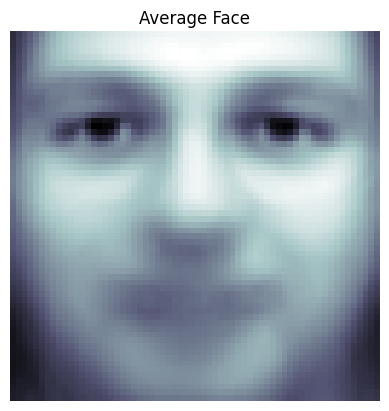

[[-0.00459799 -0.004831   -0.00535324 ...  0.00179195  0.00340369
   0.00446056]
 [ 0.02820921  0.02971647  0.03184388 ... -0.02245467 -0.02321882
  -0.02369076]
 [ 0.00140589 -0.00165595 -0.0053747  ... -0.01777245 -0.0185251
  -0.01695074]
 ...
 [-0.0351087  -0.03331936 -0.017808   ... -0.02228277 -0.01850301
   0.01760605]
 [ 0.019184    0.01935485 -0.00106198 ... -0.00132009  0.00352589
  -0.01723588]
 [ 0.00343482  0.00847388  0.00687772 ... -0.00325172 -0.0065011
  -0.02920862]]

 Principal Components Shape is: (150, 4096)


In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=150, whiten=True)
pca.fit(X_train)

mean_face = np.mean(X_train.to_numpy(), axis=0)
rotated_mean_face_image = (np.rot90(mean_face.reshape(64, 64), k=-1))

plt.imshow(rotated_mean_face_image, cmap='bone')
plt.axis('off')
plt.title('Average Face')
plt.show()

print(pca.components_)
print('\n Principal Components Shape is:', pca.components_.shape)

## Explained Variance

In [9]:
# Calculate total explained variance
total_variance = np.sum(pca.explained_variance_)
print("\n\n Sum of total variance is:", total_variance)

# Calculate the percentage of explained variance for each principal compontnet
explained_variance_percentage = (pca.explained_variance_ / total_variance) * 100

# Print the percentage of explained variance
print(f'\n Variance (%) for each of the {len(pca.explained_variance_)} principal components!')
print(explained_variance_percentage)

# Calculation of total explained variance from the first 10 principal components
pc10_variance = np.sum(pca.explained_variance_[:10])
print("\n Percentage of total variance explained by the first 10 principal components:", (pc10_variance / total_variance) * 100)

# Initialize variable for full explained variance
cumulative_explained_variance = 0

# Initialize variable for number of components
num_components = 0

# Threshold
threshold = 95.0

# Iterate through percentages of explained variance
for explained_variance in explained_variance_percentage:
    cumulative_explained_variance += explained_variance
    num_components += 1
    if cumulative_explained_variance >= threshold:
        print(f'\n Number of components that explain {threshold} (%) of total variance is --> {num_components}')
        break



 Sum of total variance is: 4475925.280652145

 Variance (%) for each of the 150 principal components!
[24.54611825 13.53708345  8.62682306  5.23057188  3.80623618  3.35495998
  2.49249133  2.15713693  1.98544072  1.74514896  1.6373832   1.51587418
  1.32904796  1.24587082  1.16804125  0.98679816  0.90436025  0.87588188
  0.80154225  0.76596592  0.75564116  0.66195464  0.61587126  0.58698537
  0.57886365  0.56143146  0.53474274  0.51612633  0.49467833  0.47049349
  0.4499144   0.41673279  0.39244403  0.35741512  0.3495622   0.33781961
  0.33144139  0.32582058  0.29941824  0.29513359  0.28585681  0.27565748
  0.26248576  0.25589475  0.2527533   0.24590811  0.24355352  0.23629918
  0.22229962  0.21697878  0.20770078  0.20428191  0.2001344   0.195981
  0.19320816  0.18621927  0.18254647  0.17984231  0.17581808  0.17276888
  0.16775288  0.16564193  0.15946569  0.15388871  0.15273337  0.14687414
  0.14590829  0.14411856  0.14245694  0.13929008  0.13769963  0.13121954
  0.13048731  0.125923

## Support Vector Machines (SVΜ) / Support Vector Classifier (SVC)

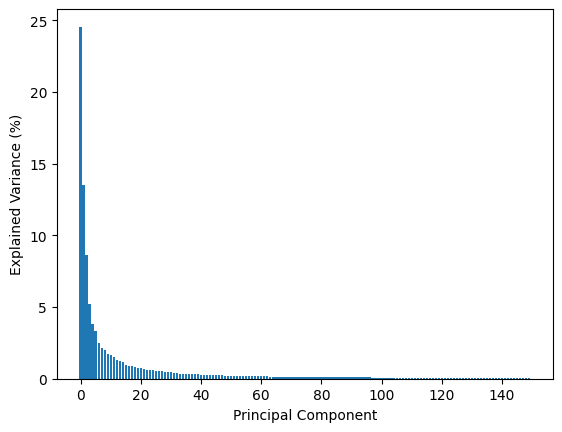

(320, 150)
(80, 150)
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      0.50      0.67         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         2
          17       1.00      1.00      1.00         2
      

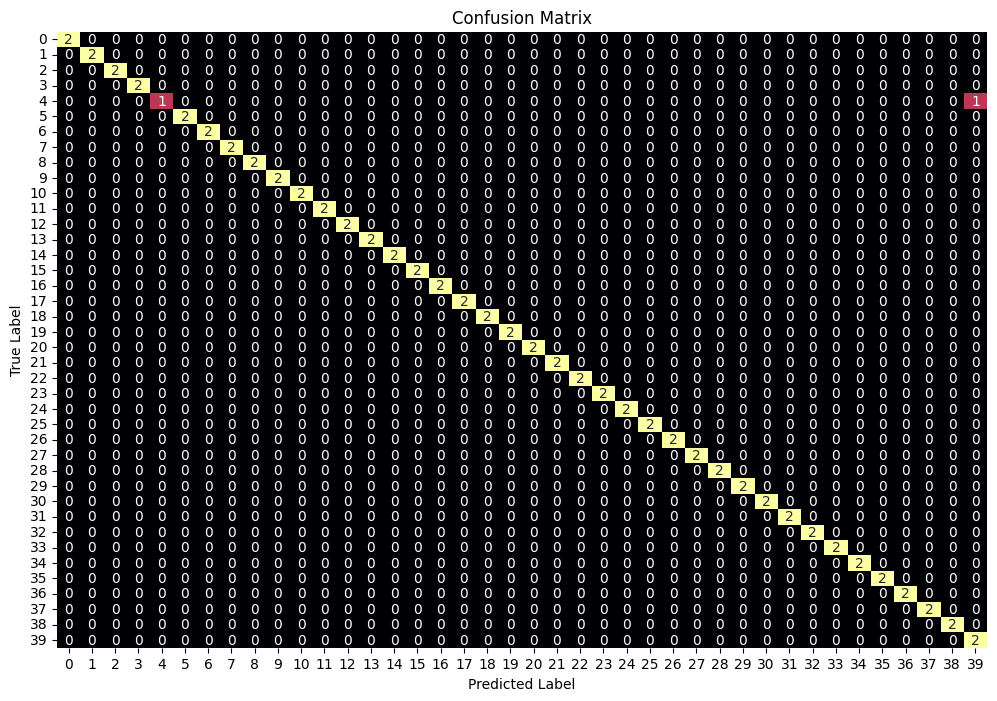

In [10]:
from sklearn.svm import SVC
import seaborn as sns

# Plot the explained variance percentage for all principal components.
explained_variance_percentage = (pca.explained_variance_ / np.sum(pca.explained_variance_)) * 100
plt.bar(range(len(explained_variance_percentage)), explained_variance_percentage)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.show()

# With this projection computed, we can now project our original training and test data onto the PCA basis:
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print(X_train_pca.shape)
print(X_test_pca.shape)

# Flatten the labels to 1D.
y_train = y_train.ravel()
y_test = y_test.ravel()

# Doing the Learning: Support Vector Machines.
clf = SVC(C=5., gamma=0.001)
clf.fit(X_train_pca, y_train)

y_pred = clf.predict(X_test_pca)
class_report = classification_report(y_test, y_pred)
print(class_report)

# Calculate the confusion matrix
confusion_mat = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="inferno", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()